# Spain vs Portugal — Control, Transition Risk and Knockout Uncertainty

## Objective

Build an opponent-specific pre-match model for Spain vs Portugal by using the Spain vs Austria project as a validation point, separating Spain's control-based route to dominance from Portugal's transition-based route to danger, and estimating not only 90-minute outcomes but also extra-time and penalty-shootout scenarios.

## Core thesis

**Spain's biggest advantage is control. Portugal's biggest threat is what happens when that control breaks.**

The purpose of the notebook is not simply to say who is more likely to win. The purpose is to explain:

1. which parts of Spain's performance against Austria are repeatable;
2. which parts become risky against Portugal;
3. how the model changes after the Austria post-match audit;
4. how uncertainty, extra time and penalties affect qualification probability.

## 1. Project setup

All figures are generated directly inside this notebook. The notebook does not load pre-made images.

In [1]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch
from matplotlib.lines import Line2D

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

SPAIN = "#C8102E"
PORTUGAL = "#006B3F"
DARK = "#111827"
MUTED = "#6B7280"
GRID = "#E5E7EB"
LIGHT = "#F8FAFC"
AMBER = "#F59E0B"
BLUE = "#2563EB"
PURPLE = "#7C3AED"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": GRID,
    "axes.labelcolor": DARK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.size": 10,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
})


def savefig(fig, filename):
    path = OUTPUT_DIR / filename
    fig.savefig(path, dpi=240, facecolor="white", bbox_inches="tight")
    print(f"Saved: {path.relative_to(PROJECT_ROOT)}")
    return path


def wavg(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    return np.average(values, weights=weights)


def wstd(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mu = np.average(values, weights=weights)
    return np.sqrt(np.average((values - mu) ** 2, weights=weights))


def minmax_score(value, low, high, invert=False):
    if high == low:
        score = 50
    else:
        score = (value - low) / (high - low) * 100
    score = float(np.clip(score, 0, 100))
    return 100 - score if invert else score


def lognormal_params_from_mean_cv(mean, cv):
    sigma = math.sqrt(math.log(1 + cv**2))
    mu = math.log(mean) - 0.5 * sigma**2
    return mu, sigma

## 2. Data design: current World Cup first, preparation second

The data layer is deliberately weighted. Current World Cup matches should dominate the estimate because they are the closest representation of current form, tactical rhythm and tournament context. Preparation and comparable matches are still included, but with lower influence.

The final match weight uses three components:

\[
W_i = W_{base,i} 	imes W_{recency,i} 	imes W_{opponent,i}
\]

Where:

- `base_weight` gives the current World Cup more importance;
- `recency_weight` gradually downweights older matches;
- `opponent_weight` gives slightly more value to stronger opponents.

In [2]:
logs = pd.read_csv(DATA_DIR / "match_logs_master.csv", parse_dates=["date"])
tactical = pd.read_csv(DATA_DIR / "tactical_priors.csv").set_index("team")
validation = pd.read_csv(DATA_DIR / "austria_model_validation.csv")
penalty_inputs = pd.read_csv(DATA_DIR / "penalty_inputs.csv").set_index("team")

reference_date = logs["date"].max()
logs["days_ago"] = (reference_date - logs["date"]).dt.days
logs["recency_weight"] = np.exp(-logs["days_ago"] / 55)
logs["opponent_weight"] = 0.85 + 0.30 * logs["opponent_strength"]
logs["model_weight"] = logs["base_weight"] * logs["recency_weight"] * logs["opponent_weight"]

weight_summary = logs.groupby(["team", "match_group"])["model_weight"].sum().unstack(fill_value=0)
weight_share = weight_summary.div(weight_summary.sum(axis=1), axis=0)

print("Model-weight share by data source")
display((weight_share * 100).round(1))
display(logs[["team", "opponent", "match_group", "match_type", "date", "base_weight", "recency_weight", "opponent_weight", "model_weight"]].round(3))

Model-weight share by data source


match_group,comparable,current_world_cup,preparation
team,,,
Portugal,0.2,82.9,16.8
Spain,0.3,83.2,16.6


,team,opponent,match_group,match_type,date,base_weight,recency_weight,opponent_weight,model_weight
0,Spain,Austria,current_world_cup,R32,2026-07-02,2.00,1.000,1.084,2.168
1,Spain,Uruguay,current_world_cup,Group,2026-06-26,1.65,0.897,1.108,1.639
2,Spain,Cape Verde,current_world_cup,Group,2026-06-21,1.55,0.819,1.036,1.315
3,Spain,Saudi Arabia,current_world_cup,Group,2026-06-16,1.45,0.748,1.054,1.143
4,Spain,Croatia,preparation,Preparation,2026-06-07,0.95,0.635,1.099,0.663
5,Spain,France,preparation,Preparation,2026-06-02,0.90,0.580,1.126,0.587
6,Spain,Germany,comparable,Comparable,2025-11-18,0.70,0.016,1.120,0.013
7,Spain,Italy,comparable,Comparable,2025-10-12,0.65,0.008,1.102,0.006
8,Portugal,Croatia,current_world_cup,R32,2026-07-02,2.00,1.000,1.099,2.198
9,Portugal,DR Congo,current_world_cup,Group,2026-06-26,1.65,0.897,1.060,1.568


## 3. Previous model audit: what did the Austria model miss?

This is the bridge between the previous project and the new model. The Austria model was directionally useful: it correctly identified Spain as the stronger side. But it also revealed two limitations:

1. the model did not need to stress transition risk heavily against Austria;
2. it slightly underestimated Spain's high recoveries and shot-on-target ceiling.

Against Portugal, the model must therefore become more opponent-specific: the transition layer and turnover exposure cannot be secondary variables.

In [3]:
validation["inside_interval"] = validation["actual"].between(validation["previous_low"], validation["previous_high"])
validation["error_vs_mid"] = validation["actual"] - validation["previous_mid"]
validation["abs_error_vs_mid"] = validation["error_vs_mid"].abs()

coverage = validation["inside_interval"].mean()
mean_abs_error = validation["abs_error_vs_mid"].mean()

print(f"Interval coverage: {coverage:.1%}")
print(f"Mean absolute error vs midpoint: {mean_abs_error:.2f}")
display(validation)

Interval coverage: 42.9%
Mean absolute error vs midpoint: 1.69


,metric,team,previous_low,previous_mid,previous_high,actual,unit,inside_interval,error_vs_mid,abs_error_vs_mid
0,Possession,Spain,63.0,67.00,71.0,64.00,%,True,-3.00,3.00
1,Possession,Austria,31.0,33.00,35.0,36.00,%,False,3.00,3.00
2,xG,Spain,1.5,1.90,2.3,2.45,xG,False,0.55,0.55
3,xG,Austria,0.6,0.75,0.9,0.55,xG,False,-0.20,0.20
4,Goals,Spain,1.0,1.85,2.7,3.00,goals,False,1.15,1.15
5,Goals,Austria,0.4,0.75,1.1,0.00,goals,False,-0.75,0.75
6,Shots,Spain,13.0,16.50,20.0,17.00,shots,True,0.50,0.50
7,Shots,Austria,5.0,6.50,8.0,6.00,shots,True,-0.50,0.50
8,Shots on target,Spain,4.0,5.00,6.0,7.00,shots,False,2.00,2.00
9,Shots on target,Austria,2.0,2.50,3.0,2.00,shots,True,-0.50,0.50


Saved: outputs/01_austria_model_audit_interval_calibration.png


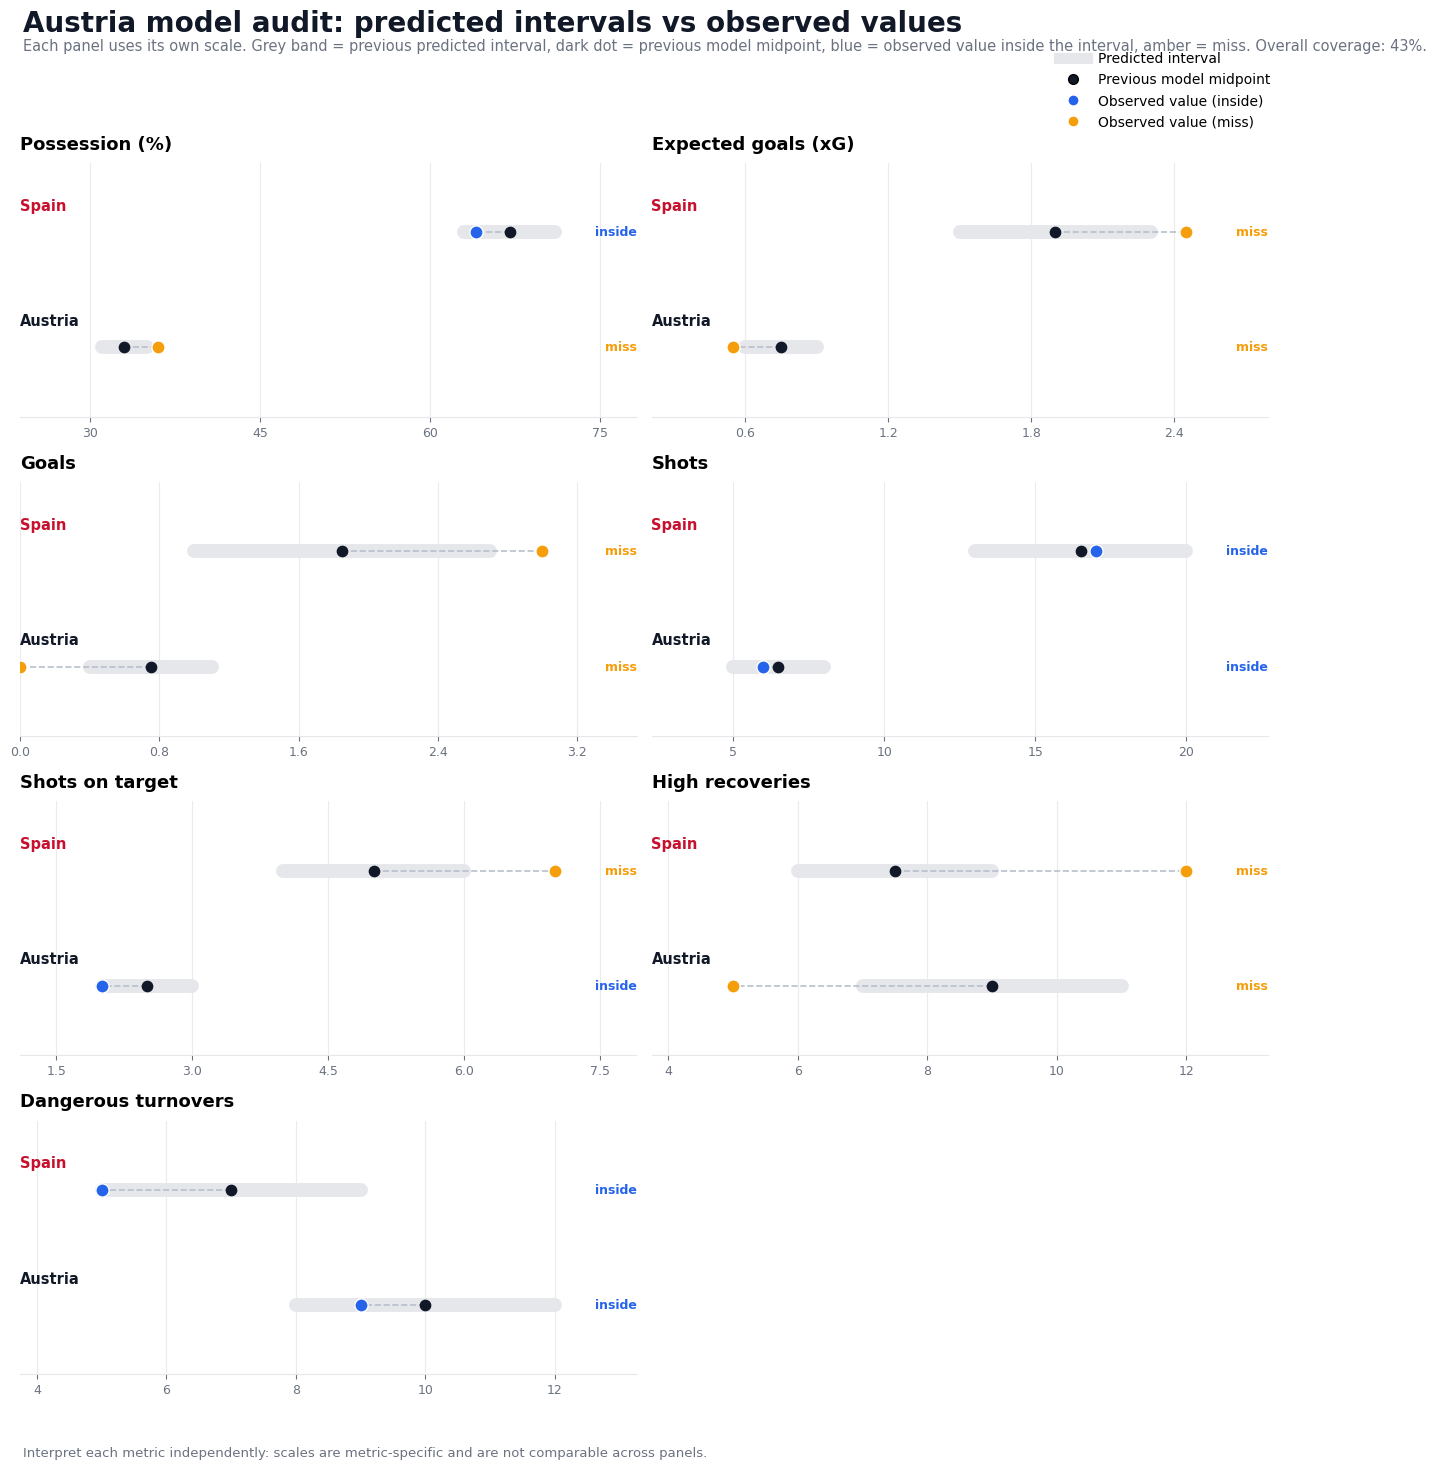

In [4]:
import math
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

metric_order = [
    "Possession",
    "xG",
    "Goals",
    "Shots",
    "Shots on target",
    "High recoveries",
    "Dangerous turnovers"
]

metric_titles = {
    "Possession": "Possession (%)",
    "xG": "Expected goals (xG)",
    "Goals": "Goals",
    "Shots": "Shots",
    "Shots on target": "Shots on target",
    "High recoveries": "High recoveries",
    "Dangerous turnovers": "Dangerous turnovers"
}

team_order = ["Spain", "Austria"]

plot_df = validation.copy()
plot_df = plot_df[plot_df["metric"].isin(metric_order)].copy()
plot_df["metric"] = pd.Categorical(plot_df["metric"], categories=metric_order, ordered=True)
plot_df["team"] = pd.Categorical(plot_df["team"], categories=team_order, ordered=True)

n_metrics = len(metric_order)
ncols = 2
nrows = math.ceil(n_metrics / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 15))
axes = axes.flatten()

for ax, metric in zip(axes, metric_order):
    sub = plot_df[plot_df["metric"] == metric].sort_values("team").copy()

    y_map = {"Spain": 1, "Austria": 0}

    xmin = min(sub["previous_low"].min(), sub["actual"].min(), sub["previous_mid"].min())
    xmax = max(sub["previous_high"].max(), sub["actual"].max(), sub["previous_mid"].max())
    span = xmax - xmin
    pad = span * 0.18 if span > 0 else 1.0

    left = xmin - pad
    right = xmax + pad

    if metric in ["Possession", "xG", "Goals", "Shots", "Shots on target", "High recoveries", "Dangerous turnovers"]:
        left = max(0, left)

    ax.set_xlim(left, right)
    ax.set_ylim(-0.6, 1.6)

    for _, row in sub.iterrows():
        y = y_map[row["team"]]
        obs_color = BLUE if row["inside_interval"] else AMBER

        ax.hlines(
            y,
            row["previous_low"],
            row["previous_high"],
            color=GRID,
            lw=10,
            zorder=1,
            capstyle="round"
        )

        ax.plot(
            [row["previous_mid"], row["actual"]],
            [y, y],
            color="#B8C0CC",
            lw=1.2,
            ls="--",
            zorder=2
        )

        ax.scatter(
            row["previous_mid"],
            y,
            s=55,
            color=DARK,
            zorder=3
        )

        ax.scatter(
            row["actual"],
            y,
            s=90,
            color=obs_color,
            edgecolor="white",
            linewidth=1.0,
            zorder=4
        )

        ax.text(
            left,
            y + 0.23,
            row["team"],
            fontsize=10.5,
            fontweight="bold",
            color=SPAIN if row["team"] == "Spain" else DARK,
            ha="left",
            va="center"
        )

        ax.text(
            right,
            y,
            "inside" if row["inside_interval"] else "miss",
            fontsize=9,
            fontweight="bold",
            color=obs_color,
            ha="right",
            va="center"
        )

    ax.set_yticks([])
    ax.set_title(
        metric_titles.get(metric, metric),
        loc="left",
        fontsize=13,
        fontweight="bold",
        pad=10
    )

    ax.grid(axis="x", color=GRID, lw=0.8, alpha=0.8)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color(GRID)

    ax.tick_params(axis="x", labelsize=9, colors=MUTED)

for j in range(len(metric_order), len(axes)):
    axes[j].axis("off")

fig.suptitle(
    "Austria model audit: predicted intervals vs observed values",
    x=0.08, y=0.985, ha="left",
    fontsize=20, fontweight="bold", color=DARK
)

fig.text(
    0.08, 0.958,
    f"Each panel uses its own scale. Grey band = previous predicted interval, dark dot = previous model midpoint, "
    f"blue = observed value inside the interval, amber = miss. Overall coverage: {coverage:.0%}.",
    fontsize=10.5, color=MUTED, ha="left"
)

fig.text(
    0.08, 0.02,
    "Interpret each metric independently: scales are metric-specific and are not comparable across panels.",
    fontsize=9.5, color=MUTED, ha="left"
)

legend_handles = [
    Line2D([0], [0], color=GRID, lw=8, label="Predicted interval"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=DARK, markersize=7, label="Previous model midpoint"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=BLUE, markeredgecolor="white", markersize=8, label="Observed value (inside)"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=AMBER, markeredgecolor="white", markersize=8, label="Observed value (miss)")
]

fig.legend(
    handles=legend_handles,
    loc="upper right",
    bbox_to_anchor=(0.98, 0.965),
    frameon=False,
    fontsize=10
)

plt.tight_layout(rect=[0.06, 0.05, 0.98, 0.94])
savefig(fig, "01_austria_model_audit_interval_calibration.png")
plt.show()

## 4. Team profiles and structural indexes

The model separates three ideas that are often mixed together:

- **Control index**: capacity to keep the game in the opponent half and progress with the ball.
- **Transition index**: capacity to create danger without long possession sequences.
- **Defensive protection index**: ability to defend the moments immediately after losing the ball.

This is the central improvement from the Austria model. Portugal is not treated as just a stronger Austria; Portugal changes the risk structure of the match.

In [5]:
metric_cols = [
    "goals_for", "goals_against", "xg_for", "xg_against", "shots_for", "shots_against", "sot_for", "sot_against",
    "possession", "final_third_entries", "box_entries", "high_recoveries", "dangerous_turnovers",
    "transition_attacks_for", "transition_attacks_against", "field_tilt", "ppda"
]

profiles = []
for team in ["Spain", "Portugal"]:
    df = logs[logs["team"] == team].copy()
    row = {"team": team}
    for col in metric_cols:
        row[col] = wavg(df[col], df["model_weight"])
        row[col + "_std"] = wstd(df[col], df["model_weight"])
    current = df[df["match_group"] == "current_world_cup"]
    prep = df[df["match_group"].isin(["preparation", "comparable"])]
    row["current_wc_xg_for"] = wavg(current["xg_for"], current["model_weight"])
    row["current_wc_xg_against"] = wavg(current["xg_against"], current["model_weight"])
    row["prep_xg_for"] = wavg(prep["xg_for"], prep["model_weight"])
    row["prep_xg_against"] = wavg(prep["xg_against"], prep["model_weight"])
    row["shot_quality"] = row["xg_for"] / max(row["shots_for"], 1)
    profiles.append(row)
profiles = pd.DataFrame(profiles).set_index("team")

ranges = {col: (logs[col].min(), logs[col].max()) for col in metric_cols}

def build_indices(team):
    p = profiles.loc[team]
    t = tactical.loc[team]
    control_components = {
        "Tactical control prior": t["control"],
        "Progression prior": t["progression"],
        "Final-third prior": t["final_third_control"],
        "Field tilt output": minmax_score(p["field_tilt"], *ranges["field_tilt"]),
        "Final-third entries": minmax_score(p["final_third_entries"], *ranges["final_third_entries"]),
        "Box access": minmax_score(p["box_entries"], *ranges["box_entries"]),
        "Ball security": t["ball_security"],
    }
    transition_components = {
        "Transition prior": t["transition_threat"],
        "Individual quality": t["individual_quality"],
        "Pressing escape": t["pressing_escape"],
        "Transition volume": minmax_score(p["transition_attacks_for"], *ranges["transition_attacks_for"]),
        "Shot quality": minmax_score(p["shot_quality"], profiles["shot_quality"].min(), profiles["shot_quality"].max()),
    }
    protection_components = {
        "Rest defence": t["rest_defence"],
        "Counterpressing": t["counterpressing"],
        "Defensive security": t["defensive_security"],
        "Transition suppression": minmax_score(p["transition_attacks_against"], *ranges["transition_attacks_against"], invert=True),
        "Low turnover exposure": minmax_score(p["dangerous_turnovers"], *ranges["dangerous_turnovers"], invert=True),
    }
    return pd.Series(control_components), pd.Series(transition_components), pd.Series(protection_components)

control_components = {}
transition_components = {}
protection_components = {}
for team in ["Spain", "Portugal"]:
    c, tr, pr = build_indices(team)
    control_components[team] = c
    transition_components[team] = tr
    protection_components[team] = pr

control_components = pd.DataFrame(control_components).T
transition_components = pd.DataFrame(transition_components).T
protection_components = pd.DataFrame(protection_components).T

indexes = pd.DataFrame(index=["Spain", "Portugal"])
indexes["Control index"] = control_components.mean(axis=1)
indexes["Transition index"] = transition_components.mean(axis=1)
indexes["Protection index"] = protection_components.mean(axis=1)
indexes["Chance quality prior"] = tactical["individual_quality"] * 0.55 + tactical["set_piece_threat"] * 0.15 + tactical["final_third_control"] * 0.30
indexes["Penalty conversion"] = tactical["penalty_conversion"]

print("Weighted team profiles")
display(profiles.round(3))
print("Structural indexes")
display(indexes.round(2))

Weighted team profiles


,goals_for,goals_for_std,goals_against,goals_against_std,xg_for,xg_for_std,xg_against,xg_against_std,shots_for,shots_for_std,shots_against,shots_against_std,sot_for,sot_for_std,sot_against,sot_against_std,possession,possession_std,final_third_entries,final_third_entries_std,box_entries,box_entries_std,high_recoveries,high_recoveries_std,dangerous_turnovers,dangerous_turnovers_std,transition_attacks_for,transition_attacks_for_std,transition_attacks_against,transition_attacks_against_std,field_tilt,field_tilt_std,ppda,ppda_std,current_wc_xg_for,current_wc_xg_against,prep_xg_for,prep_xg_against,shot_quality
team,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Spain,2.056,0.718,0.385,0.487,1.851,0.424,0.72,0.238,14.408,2.000,7.162,1.798,5.519,1.135,2.457,1.116,63.182,3.597,55.445,6.015,25.538,4.109,10.184,1.583,5.929,1.481,3.883,0.824,3.777,1.413,64.024,5.546,8.424,0.884,1.935,0.639,1.436,1.119,0.128
Portugal,1.931,0.691,1.019,0.563,1.634,0.276,1.10,0.288,13.302,1.917,10.264,2.498,5.286,1.081,4.018,1.289,54.747,4.257,44.286,4.914,20.382,2.645,6.909,0.987,8.098,1.431,7.931,0.691,5.454,1.848,51.777,5.318,10.986,0.940,1.689,0.999,1.364,1.592,0.123


Structural indexes


,Control index,Transition index,Protection index,Chance quality prior,Penalty conversion
Spain,79.32,70.74,78.21,83.3,0.76
Portugal,57.66,69.04,62.02,85.3,0.77


Saved: outputs/02_data_weighting_world_cup_vs_preparation.png


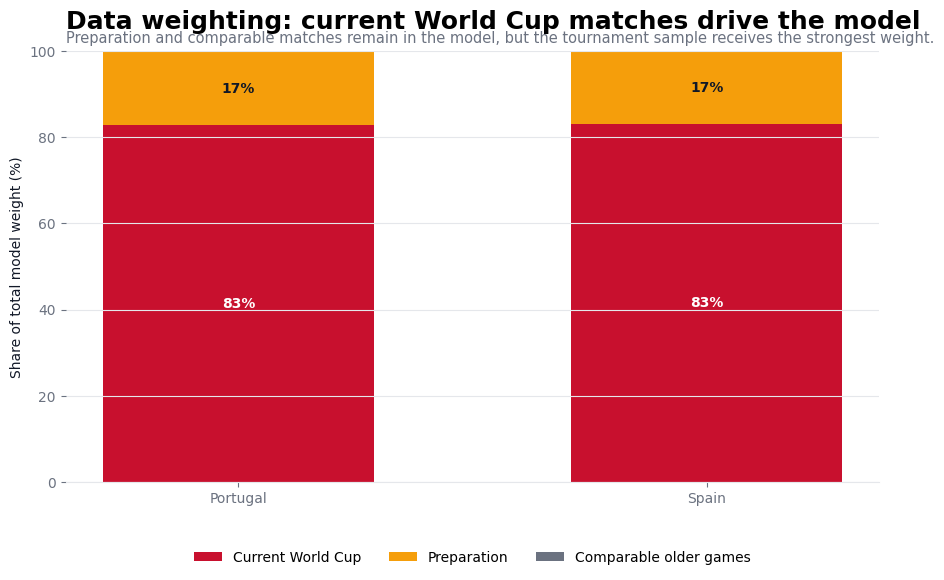

In [6]:
fig, ax = plt.subplots(figsize=(10.5, 5.6))
weight_share_plot = weight_share[["current_world_cup", "preparation", "comparable"]] * 100
bottom = np.zeros(len(weight_share_plot))
source_colors = {"current_world_cup": SPAIN, "preparation": AMBER, "comparable": MUTED}
labels = {"current_world_cup": "Current World Cup", "preparation": "Preparation", "comparable": "Comparable older games"}

for col in ["current_world_cup", "preparation", "comparable"]:
    vals = weight_share_plot[col].values
    ax.bar(weight_share_plot.index, vals, bottom=bottom, color=source_colors[col], label=labels[col], width=0.58)
    for i, v in enumerate(vals):
        if v > 8:
            ax.text(i, bottom[i] + v/2, f"{v:.0f}%", ha="center", va="center", color="white" if col == "current_world_cup" else DARK, fontweight="bold", fontsize=10)
    bottom += vals

ax.set_ylim(0, 100)
ax.set_ylabel("Share of total model weight (%)")
ax.set_title("Data weighting: current World Cup matches drive the model", loc="left", fontsize=18, pad=16)
ax.text(0, 1.02, "Preparation and comparable matches remain in the model, but the tournament sample receives the strongest weight.", transform=ax.transAxes, color=MUTED, fontsize=10.5)
ax.grid(axis="y", color=GRID, lw=0.8)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, -0.22), ncol=3)
savefig(fig, "02_data_weighting_world_cup_vs_preparation.png")
plt.show()

## 5. Style-adjusted xG model

The expected-goals model starts from weighted attacking and defensive production, then applies opponent-specific adjustments.

\[
\lambda_{Spain} = Base_{Spain} + ControlEdge + ChanceQuality + SetPiece - TransitionExposure
\]

\[
\lambda_{Portugal} = Base_{Portugal} + TransitionEdge + IndividualQuality + SetPiece - SpainControlSuppression
\]

The important part is not only the final xG value. The important part is the **route to xG**: Spain's threat is mainly control-based; Portugal's threat is more transition-based.

In [7]:
spain_base_xg = 0.58 * profiles.loc["Spain", "xg_for"] + 0.42 * profiles.loc["Portugal", "xg_against"]
portugal_base_xg = 0.58 * profiles.loc["Portugal", "xg_for"] + 0.42 * profiles.loc["Spain", "xg_against"]

spain_control_edge = (indexes.loc["Spain", "Control index"] - indexes.loc["Portugal", "Protection index"]) / 100
portugal_transition_edge = (indexes.loc["Portugal", "Transition index"] - indexes.loc["Spain", "Protection index"]) / 100
spain_chance_edge = (indexes.loc["Spain", "Chance quality prior"] - indexes.loc["Portugal", "Protection index"]) / 100
portugal_chance_edge = (indexes.loc["Portugal", "Chance quality prior"] - indexes.loc["Spain", "Protection index"]) / 100
spain_set_piece_edge = (tactical.loc["Spain", "set_piece_threat"] - indexes.loc["Portugal", "Protection index"]) / 100
portugal_set_piece_edge = (tactical.loc["Portugal", "set_piece_threat"] - indexes.loc["Spain", "Protection index"]) / 100
spain_turnover_exposure = minmax_score(profiles.loc["Spain", "dangerous_turnovers"], *ranges["dangerous_turnovers"]) / 100

xg_components = pd.DataFrame([
    ["Baseline attack vs opponent defence", spain_base_xg, portugal_base_xg],
    ["Spain control / Portugal suppression", 0.85 * spain_control_edge, -0.16 * spain_control_edge],
    ["Chance quality adjustment", 0.18 * spain_chance_edge, 0.18 * portugal_chance_edge],
    ["Portugal transition adjustment", -0.14 * portugal_transition_edge - 0.08 * spain_turnover_exposure, 0.72 * portugal_transition_edge + 0.12 * spain_turnover_exposure],
    ["Set-piece adjustment", 0.08 * spain_set_piece_edge, 0.08 * portugal_set_piece_edge],
], columns=["component", "Spain", "Portugal"])

spain_lambda = float(np.clip(xg_components["Spain"].sum(), 0.35, 3.4))
portugal_lambda = float(np.clip(xg_components["Portugal"].sum(), 0.30, 3.2))
xg_components.loc[len(xg_components)] = ["Final model xG", spain_lambda, portugal_lambda]

print(f"Final model xG: Spain {spain_lambda:.2f} — Portugal {portugal_lambda:.2f}")
display(xg_components.round(3))

Final model xG: Spain 1.72 — Portugal 1.20


,component,Spain,Portugal
0,Baseline attack vs opponent defence,1.536,1.250
1,Spain control / Portugal suppression,0.147,-0.028
2,Chance quality adjustment,0.038,0.013
3,Portugal transition adjustment,-0.009,-0.033
4,Set-piece adjustment,0.008,-0.001
5,Final model xG,1.720,1.201


Saved: outputs/03_projected_match_statistics_public_metrics.png


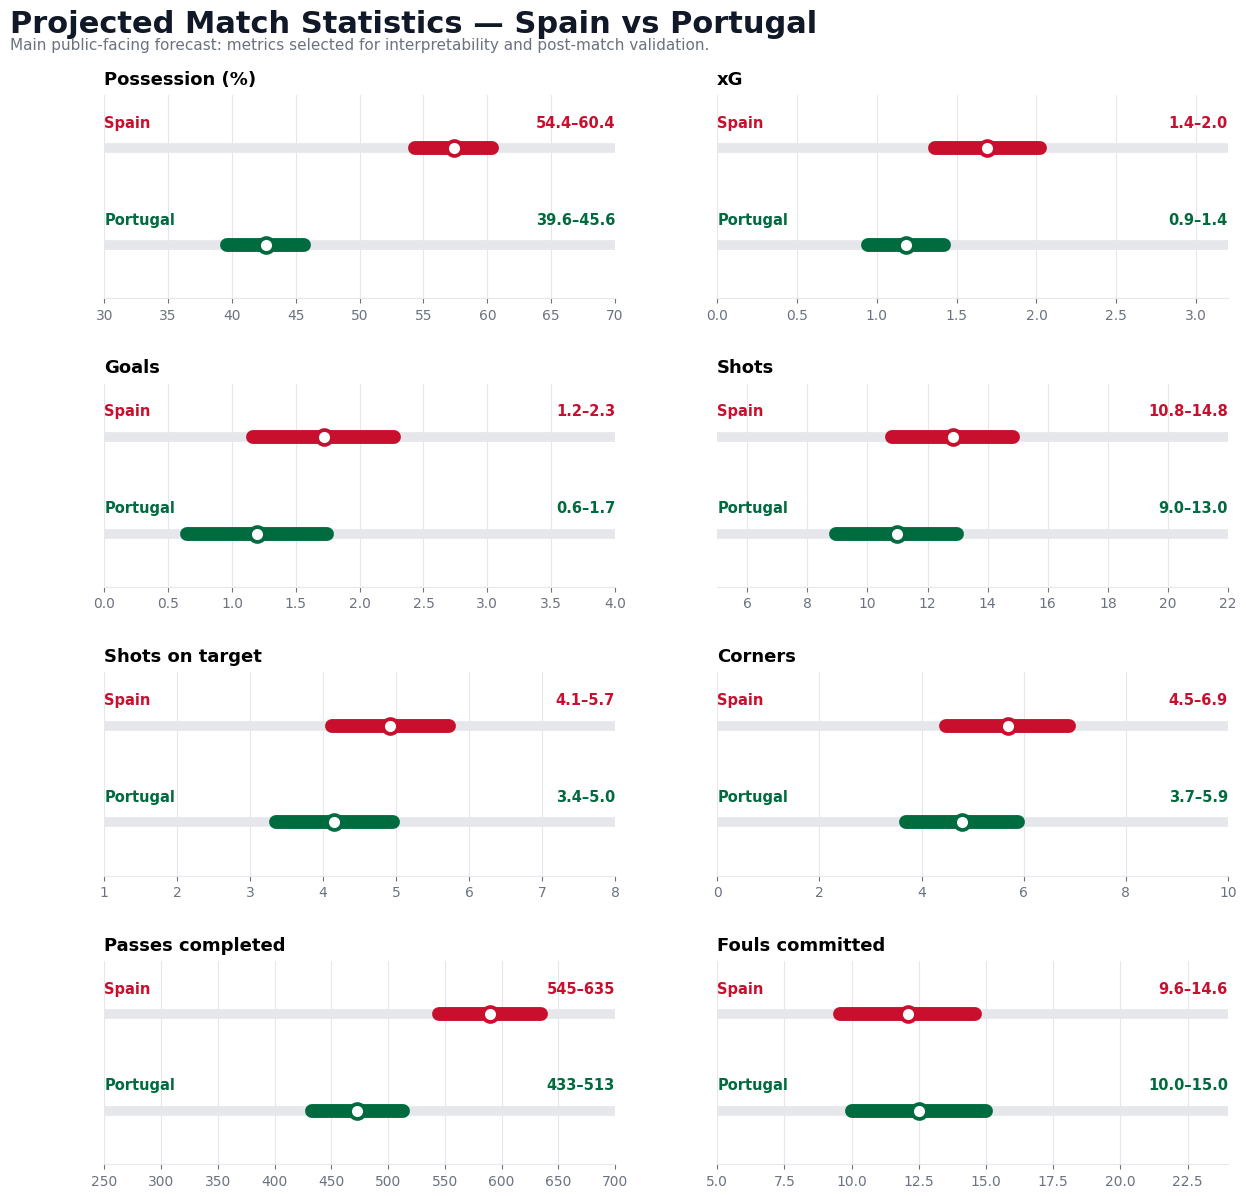

In [8]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    SPAIN
except NameError:
    SPAIN = "#C8102E"

try:
    PORTUGAL
except NameError:
    PORTUGAL = "#006B3F"

try:
    GRID
except NameError:
    GRID = "#E5E7EB"

try:
    MUTED
except NameError:
    MUTED = "#6B7280"

try:
    DARK
except NameError:
    DARK = "#111827"


def profile_value(team, col, default=None):
    """
    Safe access to profiles.loc[team, col].
    If the column does not exist, returns a model-based fallback.
    """
    if col in profiles.columns:
        return float(profiles.loc[team, col])
    return default


def add_projection(rows, metric, sp_mid, po_mid, sp_spread, po_spread, lower, upper):
    rows.extend([
        {
            "metric": metric,
            "team": "Spain",
            "mid": sp_mid,
            "low": max(lower, sp_mid - sp_spread),
            "high": min(upper, sp_mid + sp_spread),
            "axis_low": lower,
            "axis_high": upper
        },
        {
            "metric": metric,
            "team": "Portugal",
            "mid": po_mid,
            "low": max(lower, po_mid - po_spread),
            "high": min(upper, po_mid + po_spread),
            "axis_low": lower,
            "axis_high": upper
        },
    ])


try:
    lambda_s_samples
    lambda_p_samples
except NameError:
    rng = np.random.default_rng(42)

    spain_cv = max(
        0.17,
        min(
            0.33,
            profile_value("Spain", "xg_for_std", 0.35)
            / max(profile_value("Spain", "xg_for", spain_lambda), 0.1)
            * 0.55
        )
    )

    portugal_cv = max(
        0.18,
        min(
            0.36,
            profile_value("Portugal", "xg_for_std", 0.35)
            / max(profile_value("Portugal", "xg_for", portugal_lambda), 0.1)
            * 0.60
        )
    )

    mu_s, sig_s = lognormal_params_from_mean_cv(spain_lambda, spain_cv)
    mu_p, sig_p = lognormal_params_from_mean_cv(portugal_lambda, portugal_cv)

    lambda_s_samples = rng.lognormal(mu_s, sig_s, 120000)
    lambda_p_samples = rng.lognormal(mu_p, sig_p, 120000)


try:
    home_goals
    away_goals
except NameError:
    rng = np.random.default_rng(42)
    home_goals = rng.poisson(lambda_s_samples)
    away_goals = rng.poisson(lambda_p_samples)


sp_possession = np.clip(
    50 + 0.34 * (indexes.loc["Spain", "Control index"] - indexes.loc["Portugal", "Control index"]),
    46,
    64
)
pt_possession = 100 - sp_possession

sp_corners_mid = profile_value(
    "Spain",
    "corners_for",
    default=0.26 * profile_value("Spain", "shots_for", 13)
            + 0.035 * profile_value("Spain", "final_third_entries", 52)
)

pt_corners_mid = profile_value(
    "Portugal",
    "corners_for",
    default=0.26 * profile_value("Portugal", "shots_for", 12)
            + 0.030 * profile_value("Portugal", "final_third_entries", 42)
)

sp_passes_mid = profile_value(
    "Spain",
    "passes_completed",
    default=240 + 6.1 * sp_possession
)

pt_passes_mid = profile_value(
    "Portugal",
    "passes_completed",
    default=230 + 5.7 * pt_possession
)

sp_fouls_mid = profile_value(
    "Spain",
    "fouls_committed",
    default=10.5 + 0.20 * profile_value("Portugal", "transition_attacks_for", 7)
)

pt_fouls_mid = profile_value(
    "Portugal",
    "fouls_committed",
    default=11.5 + 0.18 * profile_value("Spain", "final_third_entries", 54) / 10
)


projected_rows_main = []

add_projection(
    projected_rows_main,
    "Possession (%)",
    sp_possession,
    pt_possession,
    3.0,
    3.0,
    30,
    70
)

add_projection(
    projected_rows_main,
    "xG",
    np.median(lambda_s_samples),
    np.median(lambda_p_samples),
    np.percentile(lambda_s_samples, 85) - np.median(lambda_s_samples),
    np.percentile(lambda_p_samples, 85) - np.median(lambda_p_samples),
    0,
    3.2
)

add_projection(
    projected_rows_main,
    "Goals",
    np.mean(home_goals),
    np.mean(away_goals),
    0.55,
    0.55,
    0,
    4
)

add_projection(
    projected_rows_main,
    "Shots",
    0.62 * profile_value("Spain", "shots_for", 13)
        + 0.38 * profile_value("Portugal", "shots_against", 11),
    0.62 * profile_value("Portugal", "shots_for", 12)
        + 0.38 * profile_value("Spain", "shots_against", 8),
    2.0,
    2.0,
    5,
    22
)

add_projection(
    projected_rows_main,
    "Shots on target",
    0.60 * profile_value("Spain", "sot_for", 5)
        + 0.40 * profile_value("Portugal", "sot_against", 4),
    0.60 * profile_value("Portugal", "sot_for", 5)
        + 0.40 * profile_value("Spain", "sot_against", 3),
    0.8,
    0.8,
    1,
    8
)

add_projection(
    projected_rows_main,
    "Corners",
    sp_corners_mid,
    pt_corners_mid,
    1.2,
    1.1,
    0,
    10
)

add_projection(
    projected_rows_main,
    "Passes completed",
    sp_passes_mid,
    pt_passes_mid,
    45,
    40,
    250,
    700
)

add_projection(
    projected_rows_main,
    "Fouls committed",
    sp_fouls_mid,
    pt_fouls_mid,
    2.5,
    2.5,
    5,
    24
)

projected_stats_main = pd.DataFrame(projected_rows_main)


fig, axes = plt.subplots(4, 2, figsize=(14.5, 13.2))
fig.subplots_adjust(top=0.92, hspace=0.42, wspace=0.20)

fig.suptitle(
    "Projected Match Statistics — Spain vs Portugal",
    x=0.06,
    y=0.985,
    ha="left",
    fontsize=22,
    fontweight="bold",
    color=DARK
)

fig.text(
    0.06,
    0.955,
    "Main public-facing forecast: metrics selected for interpretability and post-match validation.",
    fontsize=11,
    color=MUTED
)

for ax, metric in zip(axes.flat, projected_stats_main["metric"].unique()):
    df = projected_stats_main[projected_stats_main["metric"] == metric]
    low_axis, high_axis = df.iloc[0]["axis_low"], df.iloc[0]["axis_high"]

    ax.set_xlim(low_axis, high_axis)
    ax.set_ylim(-0.55, 1.55)

    ax.hlines([1, 0], low_axis, high_axis, color=GRID, lw=7, capstyle="round")

    for y_pos, team, color in [(1, "Spain", SPAIN), (0, "Portugal", PORTUGAL)]:
        row = df[df["team"] == team].iloc[0]

        ax.plot(
            [row["low"], row["high"]],
            [y_pos, y_pos],
            color=color,
            lw=10,
            solid_capstyle="round"
        )

        ax.scatter(
            row["mid"],
            y_pos,
            s=115,
            facecolor="white",
            edgecolor=color,
            lw=2.7,
            zorder=3
        )

        ax.text(
            low_axis,
            y_pos + 0.22,
            team,
            color=color,
            fontsize=10.5,
            fontweight="bold"
        )

        if metric in ["Passes completed"]:
            label = f"{row['low']:.0f}–{row['high']:.0f}"
        else:
            label = f"{row['low']:.1f}–{row['high']:.1f}"

        ax.text(
            high_axis,
            y_pos + 0.22,
            label,
            ha="right",
            color=color,
            fontsize=10.5,
            fontweight="bold"
        )

    ax.set_title(metric, loc="left", fontsize=13, pad=8)
    ax.set_yticks([])
    ax.grid(axis="x", color=GRID, lw=0.8)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color(GRID)

savefig(fig, "03_projected_match_statistics_public_metrics.png")
plt.show()

Saved: outputs/04_tactical_style_radar_professional.png


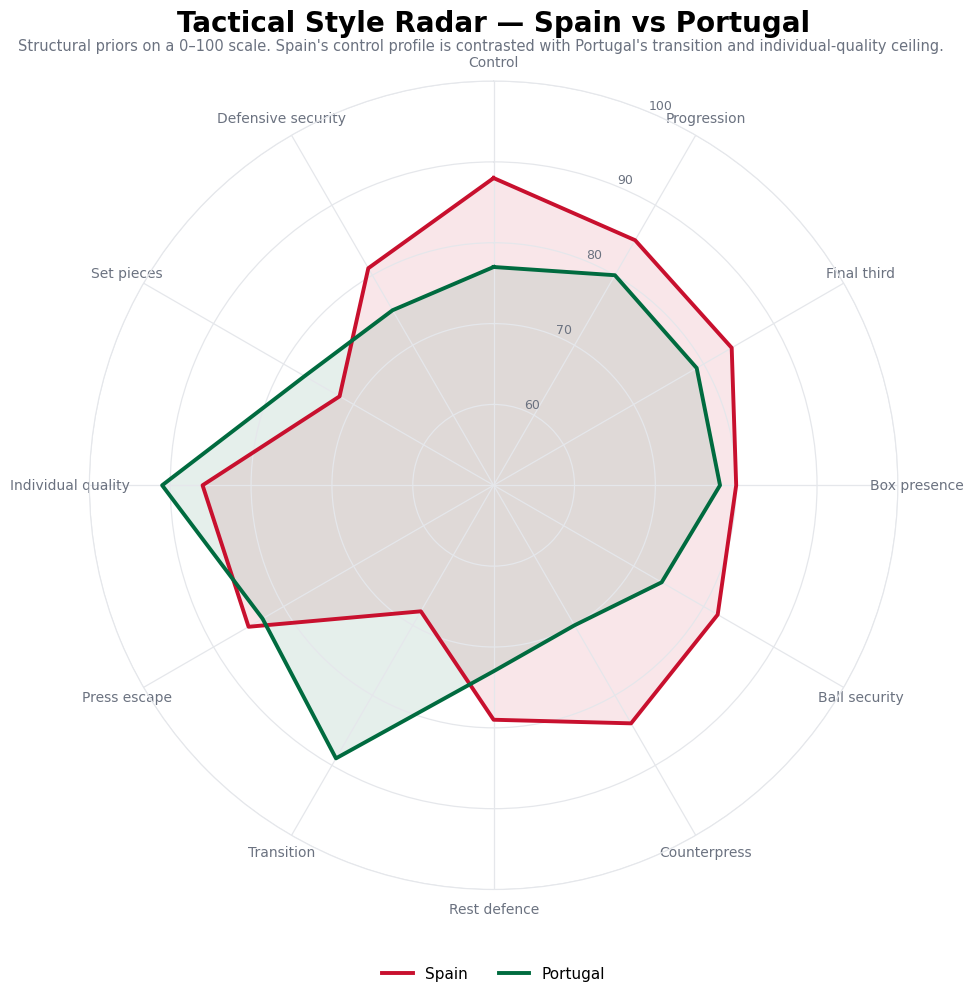

In [9]:
radar_categories = [
    "Control", "Progression", "Final third", "Box presence", "Ball security",
    "Counterpress", "Rest defence", "Transition", "Press escape", "Individual quality", "Set pieces", "Defensive security"
]
radar_cols = [
    "control", "progression", "final_third_control", "box_presence", "ball_security",
    "counterpressing", "rest_defence", "transition_threat", "pressing_escape", "individual_quality", "set_piece_threat", "defensive_security"
]

angles = np.linspace(0, 2*np.pi, len(radar_categories), endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(10.5, 10.5))
ax = plt.subplot(111, polar=True)
for team, color in [("Spain", SPAIN), ("Portugal", PORTUGAL)]:
    vals = tactical.loc[team, radar_cols].astype(float).tolist()
    vals += vals[:1]
    ax.plot(angles, vals, color=color, lw=2.8, label=team)
    ax.fill(angles, vals, color=color, alpha=0.10)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_categories, fontsize=10)
ax.set_ylim(50, 100)
ax.set_yticks([60, 70, 80, 90, 100])
ax.set_yticklabels(["60", "70", "80", "90", "100"], fontsize=9, color=MUTED)
ax.grid(color=GRID, lw=0.9)
ax.spines["polar"].set_color(GRID)
ax.set_title("Tactical Style Radar — Spain vs Portugal", fontsize=20, fontweight="bold", pad=36)
fig.text(0.5, 0.91, "Structural priors on a 0–100 scale. Spain's control profile is contrasted with Portugal's transition and individual-quality ceiling.", ha="center", color=MUTED, fontsize=10.5)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.13), ncol=2, frameon=False, fontsize=11)
savefig(fig, "04_tactical_style_radar_professional.png")
plt.show()

Saved: outputs/05_route_to_xg_decomposition.png


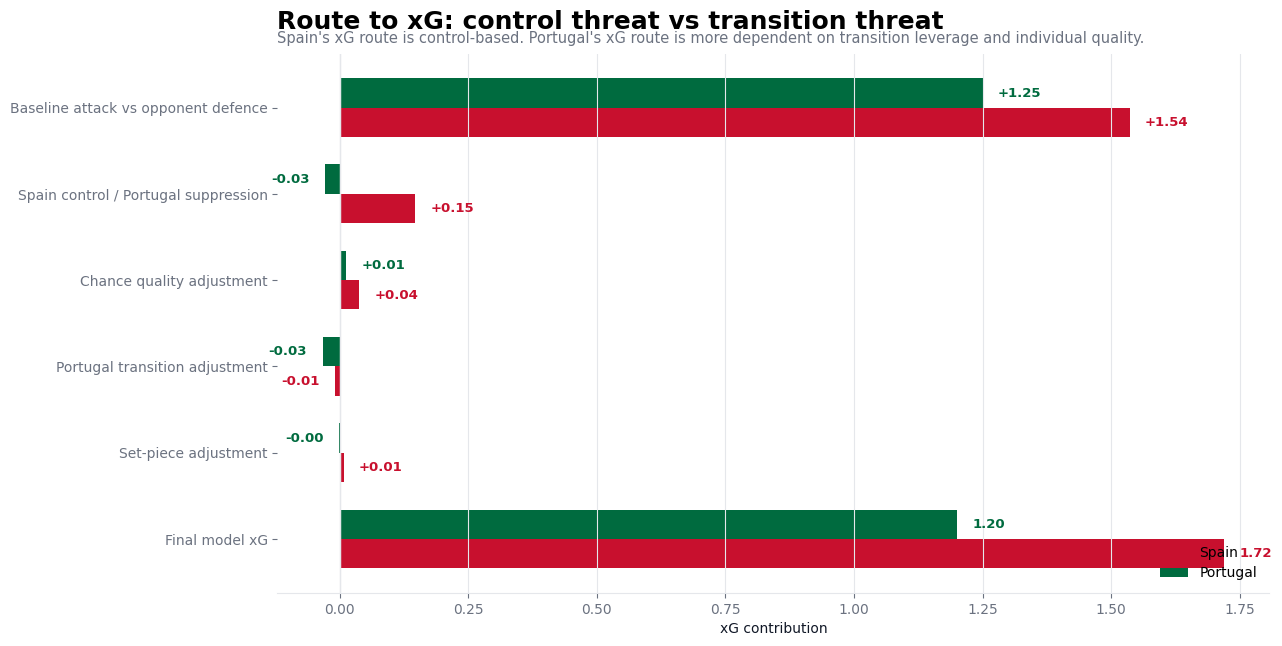

In [10]:
fig, ax = plt.subplots(figsize=(12.8, 7.0))
plot = xg_components.copy()
y = np.arange(len(plot))
h = 0.34
ax.axvline(0, color=GRID, lw=1)
ax.barh(y + h/2, plot["Spain"], height=h, color=SPAIN, label="Spain")
ax.barh(y - h/2, plot["Portugal"], height=h, color=PORTUGAL, label="Portugal")

for i, row in plot.iterrows():
    for team, offset, color in [("Spain", h/2, SPAIN), ("Portugal", -h/2, PORTUGAL)]:
        value = row[team]
        label = f"{value:.2f}" if row["component"] == "Final model xG" else f"{value:+.2f}"
        ax.text(value + (0.03 if value >= 0 else -0.03), i + offset, label, ha="left" if value >= 0 else "right", va="center", fontsize=9.5, color=color, fontweight="bold")

ax.set_yticks(y)
ax.set_yticklabels(plot["component"])
ax.invert_yaxis()
ax.set_xlabel("xG contribution")
ax.grid(axis="x", color=GRID, lw=0.8)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.set_title("Route to xG: control threat vs transition threat", loc="left", fontsize=18, pad=18)
ax.text(0, 1.02, "Spain's xG route is control-based. Portugal's xG route is more dependent on transition leverage and individual quality.", transform=ax.transAxes, color=MUTED, fontsize=10.5)
ax.legend(frameon=False, loc="lower right")
savefig(fig, "05_route_to_xg_decomposition.png")
plt.show()

## 6. Monte Carlo simulation: 90 minutes, extra time and penalties

A knockout match should not be modelled only as a 90-minute prediction. This notebook estimates:

1. the 90-minute result distribution;
2. the probability of reaching extra time;
3. the probability of reaching penalties;
4. qualification probability after including all phases.

xG uncertainty is included by sampling match-specific scoring rates before goals are simulated.

In [11]:

rng = np.random.default_rng(42)

if "lambda_s_samples" not in globals() or "lambda_p_samples" not in globals():
    raise NameError("Run the xG posterior uncertainty block before this simulation cell.")

N = len(lambda_s_samples)
spain_goals_90 = rng.poisson(lambda_s_samples)
portugal_goals_90 = rng.poisson(lambda_p_samples)

spain_win_90 = spain_goals_90 > portugal_goals_90
portugal_win_90 = portugal_goals_90 > spain_goals_90
draw_90 = spain_goals_90 == portugal_goals_90

et_intensity_factor = 0.78
spain_et_lambda = lambda_s_samples * (30 / 90) * et_intensity_factor
portugal_et_lambda = lambda_p_samples * (30 / 90) * et_intensity_factor

spain_goals_et = rng.poisson(spain_et_lambda)
portugal_goals_et = rng.poisson(portugal_et_lambda)

spain_win_et = draw_90 & (spain_goals_et > portugal_goals_et)
portugal_win_et = draw_90 & (portugal_goals_et > spain_goals_et)
penalties_needed = draw_90 & (spain_goals_et == portugal_goals_et)

spain_pen_rate = float(np.clip(
    penalty_inputs.loc["Spain", "base_conversion"] / penalty_inputs.loc["Portugal", "keeper_adjustment"],
    0.62, 0.86
))
portugal_pen_rate = float(np.clip(
    penalty_inputs.loc["Portugal", "base_conversion"] / penalty_inputs.loc["Spain", "keeper_adjustment"],
    0.62, 0.86
))

def simulate_shootout_vectorized(n, sp_rate, pt_rate, rng):
    sp = rng.random((n, 5)) < sp_rate
    pt = rng.random((n, 5)) < pt_rate
    sp_score = sp.sum(axis=1)
    pt_score = pt.sum(axis=1)
    spain_win = sp_score > pt_score
    tied = sp_score == pt_score

    for _ in range(10):
        active = tied.copy()
        if not active.any():
            break
        sp_kick = rng.random(n) < sp_rate
        pt_kick = rng.random(n) < pt_rate
        resolved = active & (sp_kick != pt_kick)
        spain_win[resolved] = sp_kick[resolved] & ~pt_kick[resolved]
        tied = active & (sp_kick == pt_kick)

    if tied.any():
        spain_win[tied] = rng.random(tied.sum()) < 0.50
    return spain_win

penalty_win = simulate_shootout_vectorized(N, spain_pen_rate, portugal_pen_rate, rng)

spain_qualifies = spain_win_90 | spain_win_et | (penalties_needed & penalty_win)
portugal_qualifies = portugal_win_90 | portugal_win_et | (penalties_needed & ~penalty_win)

phase_probs = pd.Series({
    "Spain wins in 90": spain_win_90.mean(),
    "Draw after 90": draw_90.mean(),
    "Portugal wins in 90": portugal_win_90.mean(),
    "Spain wins in ET": spain_win_et.mean(),
    "Portugal wins in ET": portugal_win_et.mean(),
    "Penalties reached": penalties_needed.mean(),
    "Spain qualifies": spain_qualifies.mean(),
    "Portugal qualifies": portugal_qualifies.mean(),
    "Spain wins shootout if reached": penalty_win[penalties_needed].mean() if penalties_needed.any() else np.nan,
})

display((phase_probs * 100).round(2).rename("Probability (%)"))


Spain wins in 90                  49.47
Draw after 90                     23.56
Portugal wins in 90               26.97
Spain wins in ET                   6.61
Portugal wins in ET                4.29
Penalties reached                 12.66
Spain qualifies                   61.82
Portugal qualifies                38.18
Spain wins shootout if reached    45.33
Name: Probability (%), dtype: float64

Saved: outputs/06_scoreline_probability_matrix_90min.png


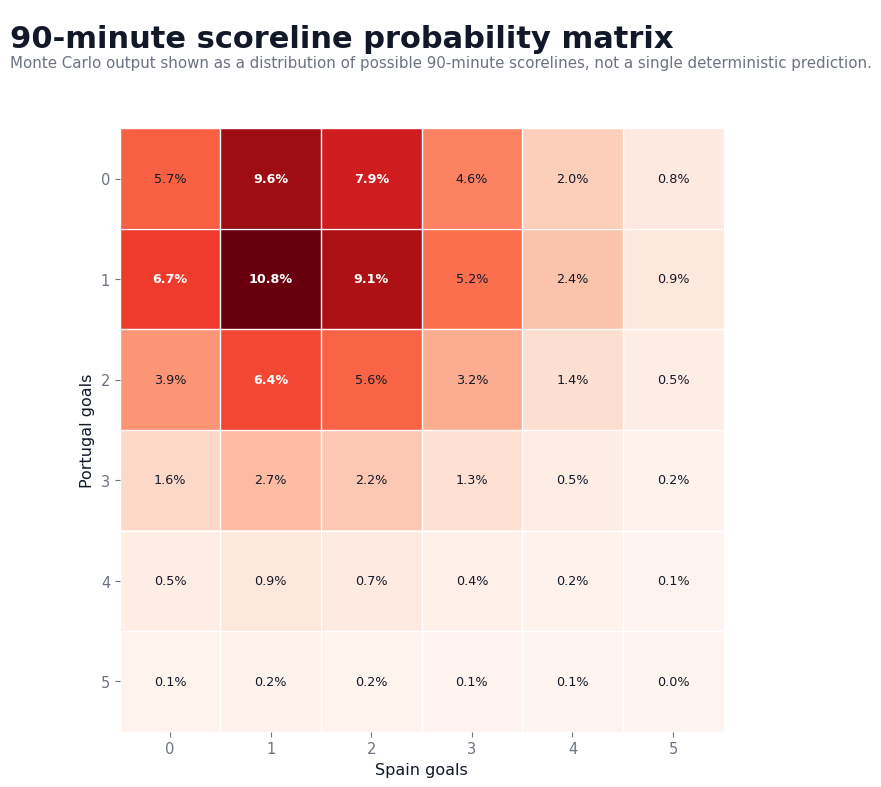

In [12]:

score_df = pd.DataFrame({"Spain": spain_goals_90, "Portugal": portugal_goals_90})
score_matrix = score_df.groupby(["Portugal", "Spain"]).size().div(N).reset_index(name="prob")

max_goals = 5
mat = np.zeros((max_goals + 1, max_goals + 1))
for _, row in score_matrix.iterrows():
    s = int(row["Spain"])
    p = int(row["Portugal"])
    if s <= max_goals and p <= max_goals:
        mat[p, s] = row["prob"] * 100

fig = plt.figure(figsize=(9.8, 8.4), facecolor="white")
gs = fig.add_gridspec(
    nrows=2,
    ncols=1,
    height_ratios=[0.70, 5.0],
    left=0.12,
    right=0.96,
    top=0.96,
    bottom=0.10,
    hspace=0.10,
)

ax_header = fig.add_subplot(gs[0])
ax = fig.add_subplot(gs[1])
ax_header.axis("off")

ax_header.text(
    0.00,
    0.82,
    "90-minute scoreline probability matrix",
    ha="left",
    va="top",
    fontsize=22,
    fontweight="bold",
    color=DARK,
    transform=ax_header.transAxes,
)

ax_header.text(
    0.00,
    0.28,
    "Monte Carlo output shown as a distribution of possible 90-minute scorelines, not a single deterministic prediction.",
    ha="left",
    va="bottom",
    fontsize=10.8,
    color=MUTED,
    transform=ax_header.transAxes,
)

im = ax.imshow(mat, cmap="Reds")

for i in range(max_goals + 1):
    for j in range(max_goals + 1):
        val = mat[i, j]
        ax.text(
            j,
            i,
            f"{val:.1f}%",
            ha="center",
            va="center",
            fontsize=9.2,
            color="white" if val > mat.max() * 0.55 else DARK,
            fontweight="bold" if val > mat.max() * 0.55 else "normal",
        )

ax.set_xticks(range(max_goals + 1))
ax.set_yticks(range(max_goals + 1))
ax.set_xlabel("Spain goals", fontsize=11.5, color=DARK)
ax.set_ylabel("Portugal goals", fontsize=11.5, color=DARK)
ax.tick_params(axis="both", labelsize=10.5, colors=MUTED)

ax.set_xticks(np.arange(-0.5, max_goals + 1, 1), minor=True)
ax.set_yticks(np.arange(-0.5, max_goals + 1, 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.0)
ax.tick_params(which="minor", bottom=False, left=False)

ax.spines[["top", "right", "left", "bottom"]].set_visible(False)

savefig(fig, "06_scoreline_probability_matrix_90min.png")
plt.show()

Saved: outputs/07_qualification_routes_clean_final.png


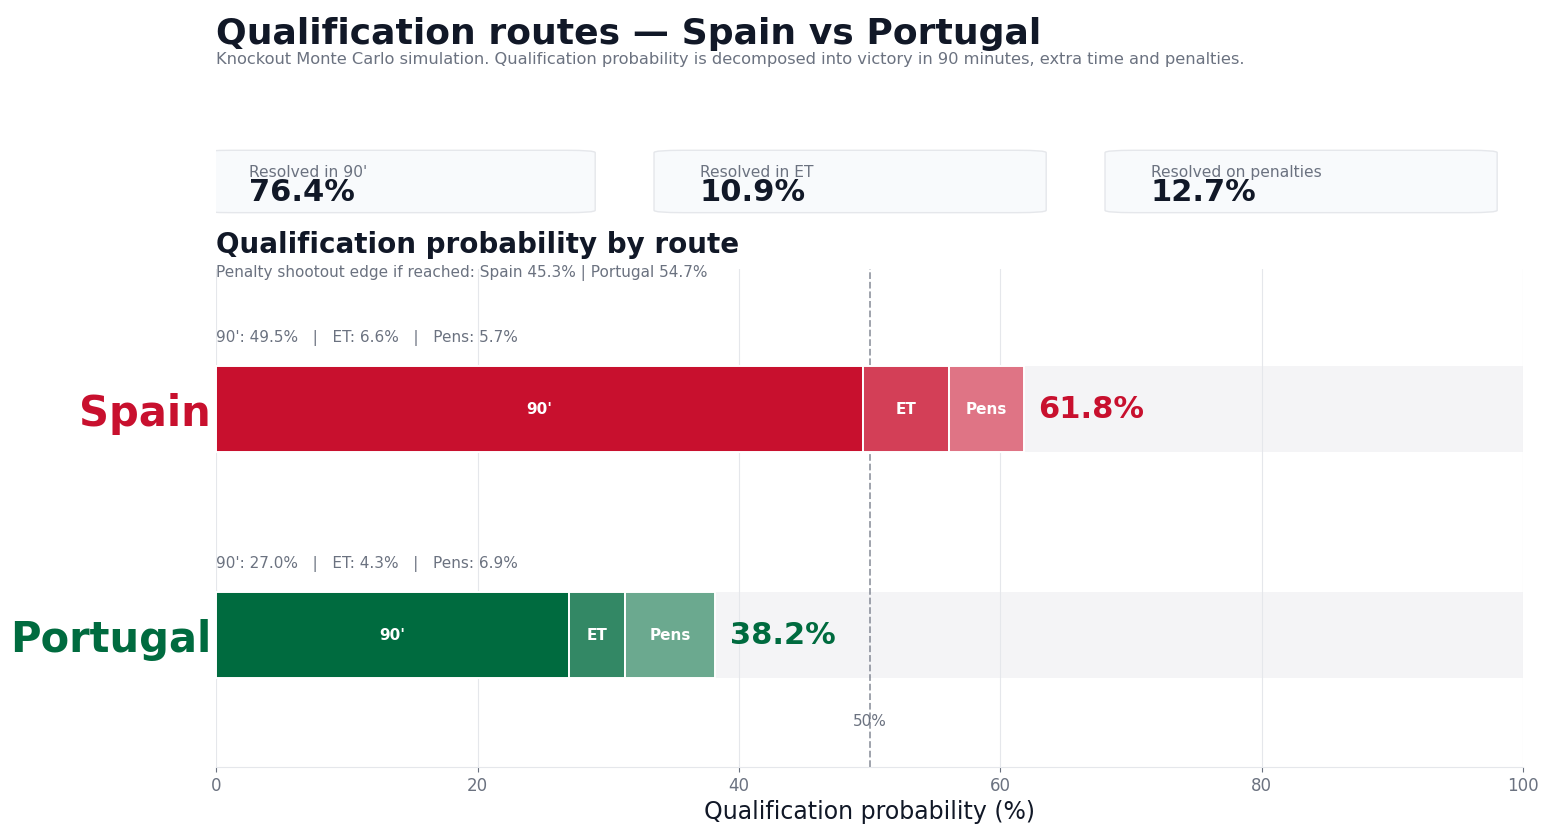

In [13]:
spain_90 = spain_win_90.mean() * 100
spain_et = spain_win_et.mean() * 100
spain_pens = (penalties_needed & penalty_win).mean() * 100

portugal_90 = portugal_win_90.mean() * 100
portugal_et = portugal_win_et.mean() * 100
portugal_pens = (penalties_needed & ~penalty_win).mean() * 100

spain_total = spain_90 + spain_et + spain_pens
portugal_total = portugal_90 + portugal_et + portugal_pens

resolved_90 = spain_90 + portugal_90
resolved_et = spain_et + portugal_et
resolved_pens = spain_pens + portugal_pens

spain_pen_edge = penalty_win[penalties_needed].mean() * 100 if penalties_needed.any() else np.nan
portugal_pen_edge = 100 - spain_pen_edge if not np.isnan(spain_pen_edge) else np.nan

def lighten(hex_color, factor=0.25):
    hex_color = hex_color.lstrip("#")
    rgb = tuple(int(hex_color[i:i+2], 16) / 255 for i in (0, 2, 4))
    new_rgb = tuple(c + (1 - c) * factor for c in rgb)
    return "#%02x%02x%02x" % tuple(int(max(0, min(1, c)) * 255) for c in new_rgb)

SPAIN_ET = lighten(SPAIN, 0.20)
SPAIN_PENS = lighten(SPAIN, 0.42)
PORTUGAL_ET = lighten(PORTUGAL, 0.20)
PORTUGAL_PENS = lighten(PORTUGAL, 0.42)

fig = plt.figure(figsize=(15.2, 8.8), facecolor="white")
gs = fig.add_gridspec(
    nrows=3,
    ncols=1,
    height_ratios=[0.75, 0.95, 4.55],
    left=0.10,
    right=0.96,
    top=0.96,
    bottom=0.10,
    hspace=0.16,
)

ax_header = fig.add_subplot(gs[0])
ax_cards = fig.add_subplot(gs[1])
ax = fig.add_subplot(gs[2])

ax_header.axis("off")
ax_cards.axis("off")

ax_header.text(
    0.00,
    0.92,
    "Qualification routes — Spain vs Portugal",
    ha="left",
    va="top",
    fontsize=26,
    fontweight="bold",
    color=DARK,
    transform=ax_header.transAxes,
)

ax_header.text(
    0.00,
    0.30,
    "Knockout Monte Carlo simulation. Qualification probability is decomposed into victory in 90 minutes, extra time and penalties.",
    ha="left",
    va="bottom",
    fontsize=11.7,
    color=MUTED,
    transform=ax_header.transAxes,
)

cards = [
    ("Resolved in 90'", resolved_90),
    ("Resolved in ET", resolved_et),
    ("Resolved on penalties", resolved_pens),
]

x_positions = [0.00, 0.345, 0.69]
card_w = 0.28
card_h = 0.58

for (label, value), x0 in zip(cards, x_positions):
    card = FancyBboxPatch(
        (x0, 0.20),
        card_w,
        card_h,
        boxstyle="round,pad=0.010,rounding_size=0.022",
        linewidth=1.0,
        edgecolor=GRID,
        facecolor=LIGHT,
        transform=ax_cards.transAxes,
    )
    ax_cards.add_patch(card)

    ax_cards.text(
        x0 + 0.025,
        0.58,
        label,
        transform=ax_cards.transAxes,
        fontsize=11.2,
        color=MUTED,
        ha="left",
        va="center",
    )

    ax_cards.text(
        x0 + 0.025,
        0.38,
        f"{value:.1f}%",
        transform=ax_cards.transAxes,
        fontsize=22,
        fontweight="bold",
        color=DARK,
        ha="left",
        va="center",
    )

ax.text(
    0.00,
    1.02,
    "Qualification probability by route",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=20,
    fontweight="bold",
    color=DARK,
)

if not np.isnan(spain_pen_edge):
    ax.text(
        0.00,
        0.975,
        f"Penalty shootout edge if reached: Spain {spain_pen_edge:.1f}% | Portugal {portugal_pen_edge:.1f}%",
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=11.0,
        color=MUTED,
    )

bar_h = 0.38
y_spain = 1
y_portugal = 0

for y in [y_spain, y_portugal]:
    ax.barh(
        y,
        100,
        color=GRID,
        alpha=0.42,
        height=bar_h,
        edgecolor="none",
        zorder=0,
    )

def draw_route_bar(y, segments, total, total_color):
    left = 0
    for label, width, color in segments:
        ax.barh(
            y,
            width,
            left=left,
            height=bar_h,
            color=color,
            edgecolor="white",
            linewidth=1.4,
            zorder=3,
        )

        if width >= 4.0:
            ax.text(
                left + width / 2,
                y,
                label,
                ha="center",
                va="center",
                fontsize=11,
                fontweight="bold",
                color="white",
                zorder=4,
            )
        left += width

    ax.text(
        total + 1.1,
        y,
        f"{total:.1f}%",
        va="center",
        ha="left",
        fontsize=22,
        fontweight="bold",
        color=total_color,
    )

spain_segments = [
    ("90'", spain_90, SPAIN),
    ("ET", spain_et, SPAIN_ET),
    ("Pens", spain_pens, SPAIN_PENS),
]

portugal_segments = [
    ("90'", portugal_90, PORTUGAL),
    ("ET", portugal_et, PORTUGAL_ET),
    ("Pens", portugal_pens, PORTUGAL_PENS),
]

draw_route_bar(y_spain, spain_segments, spain_total, SPAIN)
draw_route_bar(y_portugal, portugal_segments, portugal_total, PORTUGAL)

ax.text(
    0,
    y_spain + 0.28,
    f"90': {spain_90:.1f}%   |   ET: {spain_et:.1f}%   |   Pens: {spain_pens:.1f}%",
    fontsize=11.0,
    color=MUTED,
    ha="left",
    va="bottom",
)

ax.text(
    0,
    y_portugal + 0.28,
    f"90': {portugal_90:.1f}%   |   ET: {portugal_et:.1f}%   |   Pens: {portugal_pens:.1f}%",
    fontsize=11.0,
    color=MUTED,
    ha="left",
    va="bottom",
)

ax.axvline(
    50,
    color=MUTED,
    lw=1.3,
    ls="--",
    alpha=0.70,
    zorder=2,
)

ax.text(
    50,
    -0.38,
    "50%",
    ha="center",
    va="center",
    fontsize=11,
    color=MUTED,
)

ax.set_xlim(0, 100)
ax.set_ylim(-0.58, 1.62)

ax.set_yticks([y_spain, y_portugal])
ax.set_yticklabels(["Spain", "Portugal"], fontsize=30, fontweight="bold")
ax.get_yticklabels()[0].set_color(SPAIN)
ax.get_yticklabels()[1].set_color(PORTUGAL)

ax.set_xlabel("Qualification probability (%)", fontsize=17, color=DARK)

ax.grid(axis="x", color=GRID, lw=0.8)
ax.tick_params(axis="x", colors=MUTED, labelsize=12)
ax.tick_params(axis="y", length=0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color(GRID)

savefig(fig, "07_qualification_routes_clean_final.png")
plt.show()


## 7. Final takeaways

The final notebook keeps the analysis focused on the original objective: Spain's control route, Portugal's transition route and knockout uncertainty.

### What the model says

1. Spain's structural edge is real, especially in control, field tilt and sustained pressure.
2. Portugal are not simply a stronger version of Austria; they change the model because their transition and individual-quality routes are much stronger.
3. The key variable is not possession itself, but **possession security**.
4. The qualification view matters more than a simple 90-minute prediction: extra time and penalties materially change the interpretation of the match.
5. The most useful output is not only the probability, but the route: Spain are more likely to qualify through control in normal time, while Portugal's clearest route improves if the match becomes lower-margin and reaches penalties.

### Core sentence

**Spain's advantage is control. Portugal's opportunity is the moment that control breaks.**

In [14]:
profiles.round(4).to_csv(OUTPUT_DIR / "team_weighted_profiles.csv")
indexes.round(4).to_csv(OUTPUT_DIR / "structural_indexes.csv")
xg_components.round(4).to_csv(OUTPUT_DIR / "xg_components.csv", index=False)

if "projected_stats_main" in globals():
    projected_stats_main.round(4).to_csv(OUTPUT_DIR / "projected_match_statistics_public.csv", index=False)
if "projected_stats_tactical" in globals():
    projected_stats_tactical.round(4).to_csv(OUTPUT_DIR / "projected_match_statistics_tactical.csv", index=False)

phase_probs.rename("probability").round(5).to_csv(OUTPUT_DIR / "phase_probabilities.csv")

qualification_summary = pd.DataFrame({
    "team": ["Spain", "Portugal"],
    "qualifies": [spain_qualifies.mean(), portugal_qualifies.mean()],
    "wins_in_90": [spain_win_90.mean(), portugal_win_90.mean()],
    "wins_in_extra_time": [spain_win_et.mean(), portugal_win_et.mean()],
    "wins_on_penalties": [(penalties_needed & penalty_win).mean(), (penalties_needed & ~penalty_win).mean()],
})
qualification_summary.round(5).to_csv(OUTPUT_DIR / "qualification_route_summary.csv", index=False)

print("Outputs generated in:", OUTPUT_DIR.relative_to(PROJECT_ROOT))
for path in sorted(OUTPUT_DIR.glob("*")):
    print("-", path.name)


Outputs generated in: outputs
- 01_austria_model_audit_interval_calibration.png
- 02_data_weighting_world_cup_vs_preparation.png
- 03_projected_match_statistics_public_metrics.png
- 04_tactical_style_radar_professional.png
- 05_route_to_xg_decomposition.png
- 06_scoreline_probability_matrix_90min.png
- 07_qualification_routes_clean_final.png
- phase_probabilities.csv
- projected_match_statistics_public.csv
- qualification_route_summary.csv
- structural_indexes.csv
- team_weighted_profiles.csv
- xg_components.csv
